# Step 8 — SHAP figures (paper Fig. 5)

Retrains the two deployable `H2` regression models shown in the paper — (a) schedule + weather and (b) schedule + weather + propagation — and plots SHAP summaries at print size.

- **Input:** as in `06_propagation.ipynb`
- **Output:** `figures/fig_shap_H2_a.pdf`, `figures/fig_shap_H2_b.pdf`; SHAP values in `results/shap_H2.npz` and `results/shap_H2_X_*.pkl`

SHAP values are computed on the same 10,000 randomly sampled test flights for both models (top 12 features).

### Configuration (as in `06_propagation.ipynb`)

In [1]:
import glob, time, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
import airportsdata
from sklearn.model_selection import KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, f1_score)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'README.md').exists())  # project root
warnings.filterwarnings('ignore')

DATA = ROOT / 'data' / 'processed'
RESULTS = ROOT / 'results'; RESULTS.mkdir(parents=True, exist_ok=True)
HORIZONS = [0, 2, 6]
SEEDS = [42]
SAMPLE = 1.0
N_BOOT = 1000
TRAIN_END, VAL_END = '2022-01-01', '2022-05-01'
MAX_TURN_H = 12              # max scheduled gap (h) between previous arrival and this departure

### Aircraft rotations from the complete BTS file (as in `06_propagation.ipynb`)

In [2]:
COLS = ['FlightDate', 'Tail_Number', 'Origin', 'Dest', 'CRSDepTime', 'CRSElapsedTime',
        'DepDelay', 'ArrDelay', 'Cancelled', 'Diverted']
parts = []
for f in sorted(glob.glob(str(ROOT / 'data' / 'raw' / 'bts' / 'Combined_Flights_*.parquet'))):
    d = pd.read_parquet(f, columns=COLS)
    d = d[(d['Cancelled'] == False) & (d['Diverted'] == False)].drop(columns=['Cancelled', 'Diverted'])
    d = d.dropna(subset=['Tail_Number', 'CRSElapsedTime', 'DepDelay', 'ArrDelay'])
    parts.append(d)
    print(f'  {f}: {len(d):,}')
rot = pd.concat(parts, ignore_index=True); del parts
rot['FlightDate'] = pd.to_datetime(rot['FlightDate'])

ap = airportsdata.load('IATA')
hhmm = rot['CRSDepTime'].astype(int)
local = rot['FlightDate'] + pd.to_timedelta((hhmm // 100) * 60 + hhmm % 100, unit='m')
sdep = pd.Series(pd.NaT, index=rot.index, dtype='datetime64[ns]')
for code, idx in rot.groupby('Origin').groups.items():
    tz = ap.get(code, {}).get('tz')
    if tz is None:
        continue
    sdep.loc[idx] = (local.loc[idx].dt.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
                     .dt.tz_convert('UTC').dt.tz_localize(None).values)
rot['sdep'] = sdep
rot = rot.dropna(subset=['sdep']).reset_index(drop=True)
rot['sarr'] = rot['sdep'] + pd.to_timedelta(rot['CRSElapsedTime'], unit='m')
rot['adep'] = rot['sdep'] + pd.to_timedelta(rot['DepDelay'], unit='m')
rot['aarr'] = rot['sarr'] + pd.to_timedelta(rot['ArrDelay'], unit='m')

rot = rot.sort_values(['Tail_Number', 'sdep']).reset_index(drop=True)
same_tail = rot['Tail_Number'].eq(rot['Tail_Number'].shift(1))
prev = rot[['Dest', 'sdep', 'sarr', 'adep', 'aarr', 'DepDelay', 'ArrDelay']].shift(1)
gap_h = (rot['sdep'] - prev['sarr']).dt.total_seconds() / 3600
valid = same_tail & prev['Dest'].eq(rot['Origin']) & (gap_h >= 0) & (gap_h <= MAX_TURN_H)
print(f'{len(rot):,} legs; valid previous leg: {valid.mean():.1%}')

rot_feat = pd.DataFrame({
    'Tail_Number': rot['Tail_Number'], 'Origin': rot['Origin'], 'sdep': rot['sdep'],
    'p_sdep': prev['sdep'].where(valid), 'p_sarr': prev['sarr'].where(valid),
    'p_adep': prev['adep'].where(valid), 'p_aarr': prev['aarr'].where(valid),
    'p_depdelay': prev['DepDelay'].where(valid), 'p_arrdelay': prev['ArrDelay'].where(valid),
})
rot_feat = rot_feat.drop_duplicates(subset=['Tail_Number', 'Origin', 'sdep'], keep=False)
del rot, prev, sdep, local; gc.collect()

  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2018.parquet: 5,585,544
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2019.parquet: 7,917,263
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2020.parquet: 4,712,930
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2021.parquet: 6,185,870
  c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\data\raw\bts\Combined_Flights_2022.parquet: 3,944,916
28,343,501 legs; valid previous leg: 90.4%


42

### Join previous legs and load the flight table (as in `06_propagation.ipynb`)

In [3]:
BASE_NUM = ['Month', 'DayOfWeek', 'CRSDepHour', 'CRSArrHour', 'CRSElapsedTime', 'Distance',
            'DistanceGroup', 'DepHour_sin', 'DepHour_cos', 'Month_sin', 'Month_cos',
            'DoW_sin', 'DoW_cos', 'IsWeekend', 'IsPeakHour', 'IsHoliday']
HIGH_CARD = ['Origin', 'Dest', 'Airline', 'Tail_Number']
LOW_CARD = ['OriginState', 'DestState', 'DepTimeBlk']
df = pd.read_parquet(DATA / 'flights_clean.parquet',
                     columns=['row_id', 'FlightDate', 'dep_utc', 'ArrDelayMinutes', 'ArrDel15'] + BASE_NUM + HIGH_CARD + LOW_CARD)
df['dep_utc'] = df['dep_utc'].astype('datetime64[ns]')
m = df[['Tail_Number', 'Origin', 'dep_utc']].merge(
    rot_feat.rename(columns={'sdep': 'dep_utc'}), on=['Tail_Number', 'Origin', 'dep_utc'], how='left')
assert len(m) == len(df)
P = m.drop(columns=['Tail_Number', 'Origin']).reset_index(drop=True)
del m, rot_feat; gc.collect()
print(f'Study flights with a previous leg: {P["p_sdep"].notna().mean():.1%}')

Study flights with a previous leg: 89.9%


### Horizon-aware propagation features (as in `06_propagation.ipynb`)

In [4]:
def prop_features(H):
    t0 = df['dep_utc'] - pd.Timedelta(hours=H)
    has = P['p_sdep'].notna()
    dep_known = has & (P['p_adep'] <= t0)
    arr_known = has & (P['p_aarr'] <= t0)
    status = np.where(~has, -1, np.where(arr_known, 2, np.where(dep_known, 1, 0)))
    dep_delay = P['p_depdelay'].where(dep_known)
    arr_delay = P['p_arrdelay'].where(arr_known)
    overdue = ((t0 - P['p_sdep']).dt.total_seconds() / 60).clip(lower=0).where(has & ~dep_known)
    turn = (df['dep_utc'] - P['p_sarr']).dt.total_seconds() / 60
    known_late = arr_delay.fillna(dep_delay).fillna(overdue)
    slack = turn - known_late
    out = pd.DataFrame({'prev_status': status, 'prev_dep_delay': dep_delay, 'prev_arr_delay': arr_delay,
                        'prev_overdue_min': overdue, 'sched_turn_min': turn, 'slack_min': slack}).astype('float32')
    # --- Leakage checks ---
    assert not (out['prev_arr_delay'].notna() & ~(P['p_aarr'] <= t0)).any()
    assert not (out['prev_dep_delay'].notna() & ~(P['p_adep'] <= t0)).any()
    return out

for H in HORIZONS:
    s = prop_features(H)['prev_status'].value_counts(normalize=True).sort_index()
    print(f'H{H}: ' + ', '.join(f'{int(k)}={v:.1%}' for k, v in s.items()) +
          '   (-1 none, 0 not departed, 1 airborne, 2 arrived)')

H0: -1=10.1%, 0=0.4%, 1=3.1%, 2=86.4%   (-1 none, 0 not departed, 1 airborne, 2 arrived)
H2: -1=10.1%, 0=10.7%, 1=56.9%, 2=22.3%   (-1 none, 0 not departed, 1 airborne, 2 arrived)
H6: -1=10.1%, 0=68.6%, 1=5.9%, 2=15.4%   (-1 none, 0 not departed, 1 airborne, 2 arrived)


### Targets, split, and out-of-fold target encoding (as in `06_propagation.ipynb`)

In [5]:
tr = (df['FlightDate'] < TRAIN_END).values
va = ((df['FlightDate'] >= TRAIN_END) & (df['FlightDate'] < VAL_END)).values
te = (df['FlightDate'] >= VAL_END).values
if SAMPLE < 1.0:
    tr = tr & (np.random.RandomState(0).rand(len(df)) < SAMPLE)
y_reg = np.minimum(df['ArrDelayMinutes'].astype('float32').values,
                   np.quantile(df['ArrDelayMinutes'].values[tr], 0.999))
y_cls = df['ArrDel15'].astype('int8').values
print(f'Train {tr.sum():,} | Val {va.sum():,} | Test {te.sum():,}')


def target_encode_oof(col, y, m=10.0, n_folds=5, seed=0):
    prior = y[tr].mean(); out = np.full(len(col), np.nan, dtype='float32'); vals = col.values
    def fit_apply(fi, ai):
        s = pd.DataFrame({'k': vals[fi], 'y': y[fi]}).groupby('k')['y'].agg(['sum', 'count'])
        out[ai] = pd.Series(vals[ai]).map((s['sum'] + m * prior) / (s['count'] + m)).fillna(prior).values
    tri = np.where(tr)[0]
    for f_i, a_i in KFold(n_folds, shuffle=True, random_state=seed).split(tri):
        fit_apply(tri[f_i], tri[a_i])
    fit_apply(tri, np.where(~tr)[0])
    return out


X_base = df[BASE_NUM].astype('float32').copy()
for c in HIGH_CARD:
    X_base[f'{c}_te'] = target_encode_oof(df[c].astype(str), y_cls.astype('float32'))
for c in LOW_CARD:
    X_base[c] = df[c].astype('category')
dates_test = df.loc[te, 'FlightDate'].values

Train 8,550,324 | Val 792,335 | Test 638,672


### Train the two H2 regression models
Same LightGBM parameters as in `05_modeling_horizon.ipynb` (L2 objective, early stopping on validation, seed 42).

In [6]:
PARAMS = dict(objective='regression', metric='l1', learning_rate=0.05, num_leaves=255, min_data_in_leaf=200,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, lambda_l2=1.0, verbose=-1, seed=42,
              num_threads=-1, max_cat_to_onehot=16)
H = 2
W = pd.read_parquet(DATA / f'wx_H{H}.parquet').drop(columns='row_id').astype('float32')
PF = prop_features(H)

def train_reg(X):
    dtr = lgb.Dataset(X[tr], label=y_reg[tr])
    dva = lgb.Dataset(X[va], label=y_reg[va], reference=dtr)
    m = lgb.train(PARAMS, dtr, num_boost_round=3000, valid_sets=[dva], callbacks=[lgb.early_stopping(100, verbose=False)])
    print(f'  best_iteration={m.best_iteration}')
    return m

rng = np.random.RandomState(42)
te_idx = np.where(te)[0]
shap_idx = np.sort(rng.choice(te_idx, size=10_000, replace=False))   # same 10k flights for both panels

MODELS = {}
for key, parts in [('a', [X_base, W]), ('b', [X_base, PF, W])]:
    X = pd.concat(parts, axis=1)
    print(f'Training model ({key}) with {X.shape[1]} features...')
    MODELS[key] = (train_reg(X), X.iloc[shap_idx].copy())
    del X; gc.collect()

Training model (a) with 86 features...
  best_iteration=1415
Training model (b) with 92 features...
  best_iteration=719


### Compute and save SHAP values

In [7]:
import shap
SHAP = {}
for key, (m, Xs) in MODELS.items():
    SHAP[key] = (shap.TreeExplainer(m).shap_values(Xs), Xs)
    print(key, SHAP[key][0].shape)
np.savez_compressed(RESULTS / 'shap_H2.npz',
                    **{f'sv_{k}': v[0] for k, v in SHAP.items()},
                    **{f'cols_{k}': np.array(v[1].columns) for k, v in SHAP.items()})
for k, v in SHAP.items():
    v[1].to_pickle(RESULTS / f'shap_H2_X_{k}.pkl')
print('saved results/shap_H2.npz and results/shap_H2_X_*.pkl')

a (10000, 86)
b (10000, 92)
saved results/shap_H2.npz and results/shap_H2_X_*.pkl


### Plot
Each panel is 2.3 × 2.75 in to fit half of the LNCS text width without scaling; top 12 features with readable names. Gray points denote the categorical departure time block. Change `TOP_K` to show more features.

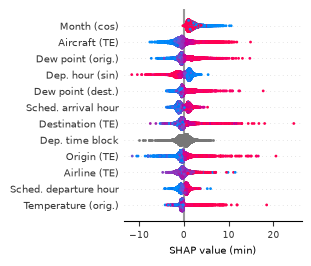

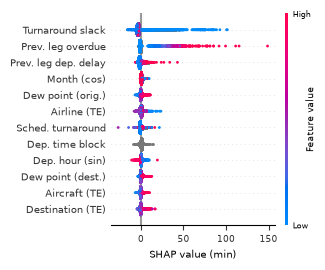

saved c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\figures\fig_shap_H2_a.pdf and c:\Users\Admin\Downloads\on-going assement 1\source_code - Copy\figures\fig_shap_H2_b.pdf


In [8]:
import matplotlib.pyplot as plt
FIG = ROOT / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
TOP_K = 12
W_IN, H_IN = 2.3, 2.75

BASE = {'dewpt_f': 'Dew point', 'temp_f': 'Temperature', 'slp': 'Sea-level pressure', 'humidity': 'Humidity',
        'thunder_3h': 'Thunder, last 3 h', 'has_thunder': 'Thunder', 'precip_in': 'Precipitation', 'precip_3h': 'Precip., last 3 h',
        'visibility_mi': 'Visibility', 'vis_min_3h': 'Min. visibility, 3 h', 'ceiling_ft': 'Ceiling', 'ceil_min_3h': 'Min. ceiling, 3 h',
        'wind_mph': 'Wind speed', 'wind_max_3h': 'Max. wind, 3 h', 'gust_mph': 'Gust', 'gust_excess': 'Gust excess',
        'pressure': 'Station pressure', 'slp_tend_3h': 'Pressure tendency, 3 h', 'cloud_max': 'Cloud cover',
        'flight_cat_ord': 'Flight category', 'has_rain': 'Rain', 'has_snow': 'Snow/ice', 'has_fog': 'Fog', 'has_mist': 'Mist',
        'wind_dir_sin': 'Wind dir. (sin)', 'wind_dir_cos': 'Wind dir. (cos)', 'lead_h': 'Lead time to arrival'}
OTHER = {'Month_cos': 'Month (cos)', 'Month_sin': 'Month (sin)', 'Month': 'Month', 'Tail_Number_te': 'Aircraft (TE)',
         'Dest_te': 'Destination (TE)', 'Origin_te': 'Origin (TE)', 'Airline_te': 'Airline (TE)',
         'DepHour_sin': 'Dep. hour (sin)', 'DepHour_cos': 'Dep. hour (cos)', 'CRSArrHour': 'Sched. arrival hour',
         'CRSDepHour': 'Sched. departure hour', 'DepTimeBlk': 'Dep. time block', 'CRSElapsedTime': 'Sched. duration',
         'Distance': 'Distance', 'DistanceGroup': 'Distance group', 'OriginState': 'Origin state', 'DestState': 'Dest. state',
         'DayOfWeek': 'Day of week', 'DoW_sin': 'Day of week (sin)', 'DoW_cos': 'Day of week (cos)',
         'slack_min': 'Turnaround slack', 'prev_overdue_min': 'Prev. leg overdue', 'prev_dep_delay': 'Prev. leg dep. delay',
         'prev_arr_delay': 'Prev. leg arr. delay', 'sched_turn_min': 'Sched. turnaround', 'prev_status': 'Prev. leg status'}

def pretty(c):
    if c in OTHER:
        return OTHER[c]
    for pre, tag in [('org_', ' (orig.)'), ('dst_', ' (dest.)')]:
        if c.startswith(pre):
            return BASE.get(c[len(pre):], c[len(pre):]) + tag
    return c

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans', 'Arial'], 'pdf.fonttype': 42})
for key, cbar in [('a', False), ('b', True)]:
    sv, Xs = SHAP[key]
    Xd = Xs.copy(); Xd.columns = [pretty(c) for c in Xs.columns]
    plt.figure()
    shap.summary_plot(sv, Xd, max_display=TOP_K, show=False, plot_size=(W_IN + (0.35 if cbar else 0), H_IN), color_bar=cbar)
    fig, axes = plt.gcf(), plt.gcf().axes
    ax = axes[0]
    ax.tick_params(axis='y', labelsize=7, length=0); ax.tick_params(axis='x', labelsize=6.5)
    ax.set_xlabel('SHAP value (min)', fontsize=7)
    for coll in ax.collections:
        coll.set_sizes([4])                          # smaller markers for print size
    if cbar and len(axes) > 1:
        cb = axes[-1]
        cb.tick_params(labelsize=6); cb.set_ylabel('Feature value', fontsize=6.5, labelpad=-4)
    fig.savefig(FIG / f'fig_shap_H2_{key}.pdf', bbox_inches='tight')
    fig.savefig(FIG / f'fig_shap_H2_{key}.png', dpi=200, bbox_inches='tight')
    plt.show()
print('saved', FIG / 'fig_shap_H2_a.pdf', 'and', FIG / 'fig_shap_H2_b.pdf')

### (Optional) Re-plot from saved SHAP values
Run the configuration cell, the cell below, and then the plotting cell.

In [9]:
import shap
z = np.load(RESULTS / 'shap_H2.npz', allow_pickle=True)
SHAP = {k: (z[f'sv_{k}'], pd.read_pickle(RESULTS / f'shap_H2_X_{k}.pkl')) for k in ['a', 'b']}
print({k: v[0].shape for k, v in SHAP.items()})

{'a': (10000, 86), 'b': (10000, 92)}
